# Naive Bayes 

### 1. Import necessary libraries

Import all the necessary libraries to train the Naive Bayes model.

In [2]:
#import libraries
import pickle
import pandas as pd
import numpy as np
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from pathlib import Path


### 2. Define paths

Declare the path to call the saved tf-idf features. Additionally, define the path to store the results of the training

In [3]:
#define paths
FEATURE_DIR = "C:/Users/HP/ecom-reviews-sentiment-analysis/knowledge_representation"
GRAPH_DIR = "C:/Users/HP/ecom-reviews-sentiment-analysis/model_training/results"

#load tf-idf features
with open(f"{FEATURE_DIR}/tfidf_features.pkl", "rb") as f:
    X_train = pickle.load(f)

with open(f"{FEATURE_DIR}/tfidf_X_val.pkl", "rb") as f:
    X_val = pickle.load(f)

with open(f"{FEATURE_DIR}/tfidf_X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

#load labels
with open(f"{FEATURE_DIR}/y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open(f"{FEATURE_DIR}/y_val.pkl", "rb") as f:
    y_val = pickle.load(f)

with open(f"{FEATURE_DIR}/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)


LABEL_NAMES = ["negative", "neutral", "positive"]

OUTPUT_DIR = Path(GRAPH_DIR) / "naive_bayes"
OUTPUT_DIR.mkdir(exist_ok=True)

Make sure all the loads are correct.

In [4]:
print("Training set")
print("X_train:", X_train.shape)
print("y_train:", len(y_train))

print("\nValidation set")
print("X_val:", X_val.shape)
print("y_val:", len(y_val))

print("\nTest set")
print("X_test:", X_test.shape)
print("y_test:", len(y_test))

Training set
X_train: (428, 1106)
y_train: 428

Validation set
X_val: (92, 1106)
y_val: 92

Test set
X_test: (92, 1106)
y_test: 92


### 3. Class Distribution

Print the total count of positive, negative, and neutral reviews for all three sets (train, test, validation)

In [5]:
#check class distribution
print("Training labels:")
print(pd.Series(y_train).value_counts())

print("\nValidation labels:")
print(pd.Series(y_val).value_counts())

print("\nTest labels:")
print(pd.Series(y_test).value_counts())

Training labels:
sentiment
positive    220
negative    134
neutral      74
Name: count, dtype: int64

Validation labels:
sentiment
positive    48
negative    29
neutral     15
Name: count, dtype: int64

Test labels:
sentiment
positive    47
negative    29
neutral     16
Name: count, dtype: int64


### 4. Evaluation Metrics

Define the function for calling the evaluation metrics function.

In [6]:
def evaluate_model(name, model, X_test, y_test):
    """
    Evaluate a trained classifier and return metrics.
    """

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0
    )

    accuracy = accuracy_score(y_test, y_pred)

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=LABEL_NAMES,
            zero_division=0
        )
    )

    metrics = {
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "Negative F1": round(report["negative"]["f1-score"], 4),
        "Neutral F1": round(report["neutral"]["f1-score"], 4),
        "Positive F1": round(report["positive"]["f1-score"], 4),
        "Macro Precision": round(report["macro avg"]["precision"], 4),
        "Macro Recall": round(report["macro avg"]["recall"], 4),
    }

    return metrics, y_pred

### 5. Confusion Matrix

Define the function for confusion matrix.

In [7]:
def plot_confusion_matrix(name, y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(f"Confusion Matrix - {name}")

    plt.tight_layout()

    save_path = OUTPUT_DIR / f"cm_{name.lower().replace(' ', '_')}.png"

    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Saved confusion matrix to:\n{save_path}")

### 6. Hyperparameter tuning

Define different alpha values. Print the accuracy and macro F1 results for each hyperparameter. Then, find the settings with the best validation Macro F1 score

In [8]:
alphas = [0.01, 0.1, 0.5, 1.0, 2.0]

tuning_results = []

best_alpha = None
best_macro_f1 = -1

print("=" * 60)
print("NAIVE BAYES HYPERPARAMETER TUNING")
print("=" * 60)

for alpha in alphas:

    model = MultinomialNB(alpha=alpha)

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)

    macro_f1 = f1_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(y_val, y_val_pred)

    tuning_results.append({
        "Alpha": alpha,
        "Accuracy": round(accuracy, 4),
        "Macro F1": round(macro_f1, 4)
    })

    print(
        f"Alpha = {alpha:<4} | "
        f"Accuracy = {accuracy:.4f} | "
        f"Macro F1 = {macro_f1:.4f}"
    )

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_alpha = alpha

print("\nBest Alpha:", best_alpha)
print("Best Validation Macro F1:", round(best_macro_f1, 4))

NAIVE BAYES HYPERPARAMETER TUNING
Alpha = 0.01 | Accuracy = 0.6739 | Macro F1 = 0.5592
Alpha = 0.1  | Accuracy = 0.6957 | Macro F1 = 0.5591
Alpha = 0.5  | Accuracy = 0.7174 | Macro F1 = 0.5476
Alpha = 1.0  | Accuracy = 0.6522 | Macro F1 = 0.4823
Alpha = 2.0  | Accuracy = 0.6087 | Macro F1 = 0.3984

Best Alpha: 0.01
Best Validation Macro F1: 0.5592


### 7. Validation Results

Print the hyperparameter tuning accuracy and macro F1 results. Save them in a CSV file.

In [9]:
tuning_df = pd.DataFrame(tuning_results)

print("\nValidation Results")
print(tuning_df.sort_values("Macro F1", ascending=False))

tuning_df.to_csv(
    OUTPUT_DIR / "naive_bayes_tuning_results.csv",
    index=False
)


Validation Results
   Alpha  Accuracy  Macro F1
0   0.01    0.6739    0.5592
1   0.10    0.6957    0.5591
2   0.50    0.7174    0.5476
3   1.00    0.6522    0.4823
4   2.00    0.6087    0.3984


### 8. Train Final Model

Train the final model using the best alpha value. 

In [10]:
#Train Final Model Using Best Alpha

nb_model = MultinomialNB(alpha=best_alpha)

nb_model.fit(X_train, y_train)

print(f"\nFinal model trained with alpha = {best_alpha}")


Final model trained with alpha = 0.01


### 9. Final test evaluation 

Test the model on the test dataset. Record the classification report for the test set.


Naive Bayes (alpha=0.01)
              precision    recall  f1-score   support

    negative       0.74      0.69      0.71        29
     neutral       0.50      0.19      0.27        16
    positive       0.75      0.94      0.83        47

    accuracy                           0.73        92
   macro avg       0.66      0.60      0.61        92
weighted avg       0.70      0.73      0.70        92



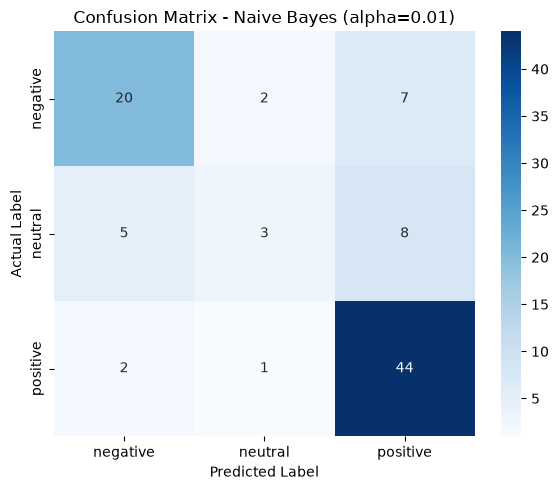

Saved confusion matrix to:
C:\Users\HP\ecom-reviews-sentiment-analysis\model_training\results\naive_bayes\cm_naive_bayes_(alpha=0.01).png


In [11]:
#Final test evaluation

test_metrics, y_test_pred = evaluate_model(
    f"Naive Bayes (alpha={best_alpha})",
    nb_model,
    X_test,
    y_test
)

plot_confusion_matrix(
    f"Naive Bayes (alpha={best_alpha})",
    y_test,
    y_test_pred
)

### 10. Save the Result

Save the final results in a CSV file.

In [12]:
#Save final results

results_df = pd.DataFrame([test_metrics])

print("\nFinal Test Results")
print(results_df)

results_df.to_csv(
    OUTPUT_DIR / "naive_bayes_final_results.csv",
    index=False
)

print(
    f"\nResults saved to:\n"
    f"{OUTPUT_DIR / 'naive_bayes_final_results.csv'}"
)


Final Test Results
                      Model  Accuracy  Macro F1  Weighted F1  Negative F1  \
0  Naive Bayes (alpha=0.01)    0.7283    0.6057       0.6967       0.7143   

   Neutral F1  Positive F1  Macro Precision  Macro Recall  
0      0.2727       0.8302           0.6622        0.6044  

Results saved to:
C:\Users\HP\ecom-reviews-sentiment-analysis\model_training\results\naive_bayes\naive_bayes_final_results.csv


### 11. Save the Model

Save the final trained Naive Bayes model.

In [13]:
#save the trained model
import pickle

with open(OUTPUT_DIR / "best_naive_bayes.pkl", "wb") as f:
    pickle.dump(nb_model, f)

print("Best Naive Bayes model saved.")

Best Naive Bayes model saved.
